In [2]:
import nltk
from nltk.corpus import gutenberg

nltk.download('gutenberg', quiet=True)

file_id = 'shakespeare-hamlet.txt'
hamlet_words = gutenberg.words(file_id)
hamlet_raw = gutenberg.raw(file_id)

total_words = len(hamlet_words)
print(f"Total number of words (including punctuation tokens): {total_words}")
print("\n--- Sample Text (First 10 lines) ---")

sample_lines = hamlet_raw.splitlines()[:10]
for line in sample_lines:
    print(line)

Total number of words (including punctuation tokens): 37360

--- Sample Text (First 10 lines) ---
[The Tragedie of Hamlet by William Shakespeare 1599]


Actus Primus. Scoena Prima.

Enter Barnardo and Francisco two Centinels.

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe


In [3]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
cleaned_text = hamlet_raw.lower()
cleaned_text = re.sub(r'[^a-z\s]', '', cleaned_text)
lines = cleaned_text.split('\n')
lines = [line.strip() for line in lines if line.strip()]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(lines)
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1 # +1 is standard practice for the zero-padding index

# Display the results
print(f"Total unique words (Vocabulary Size): {vocab_size - 1}")
print("\n--- Sample of Word Index (first 10 entries) ---")
# Convert dictionary items to a list to slice and print the first 10
for word, index in list(word_index.items())[:10]:
    print(f"'{word}': {index}")

Total unique words (Vocabulary Size): 4796

--- Sample of Word Index (first 10 entries) ---
'the': 1
'and': 2
'to': 3
'of': 4
'i': 5
'you': 6
'my': 7
'a': 8
'it': 9
'in': 10


In [4]:
input_sequences = []

for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print(f"Total input sequences generated: {len(input_sequences)}")
print("\n--- Sample of Input Sequences (first 5) ---")
for seq in input_sequences[:5]:
    print(seq)

Total input sequences generated: 25612

--- Sample of Input Sequences (first 5) ---
[1, 683]
[1, 683, 4]
[1, 683, 4, 45]
[1, 683, 4, 45, 41]
[1, 683, 4, 45, 41, 1856]


In [5]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

max_sequence_len = max([len(seq) for seq in input_sequences])

input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

X = input_sequences[:,:-1]
y = input_sequences[:,-1]

y = to_categorical(y, num_classes=vocab_size)

print(f"Max Sequence Length: {max_sequence_len}")
print(f"Shape of Predictors (X): {X.shape}")
print(f"Shape of Labels (y): {y.shape}")

Max Sequence Length: 14
Shape of Predictors (X): (25612, 13)
Shape of Labels (y): (25612, 4797)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=100, input_length=max_sequence_len-1))
model.add(LSTM(150))
model.add(Dense(vocab_size, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.0341 - loss: 6.9238
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0381 - loss: 6.4877
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0461 - loss: 6.3774
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0515 - loss: 6.2486
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0559 - loss: 6.1480
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0620 - loss: 6.0568
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0676 - loss: 5.9600
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0771 - loss: 5.8514
Epoch 9/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0884 - loss: 5.7299
Epoch 10/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0956 - loss: 5.6063
Epoch 11/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1007 - loss: 5.4908
Epoch 12/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/s

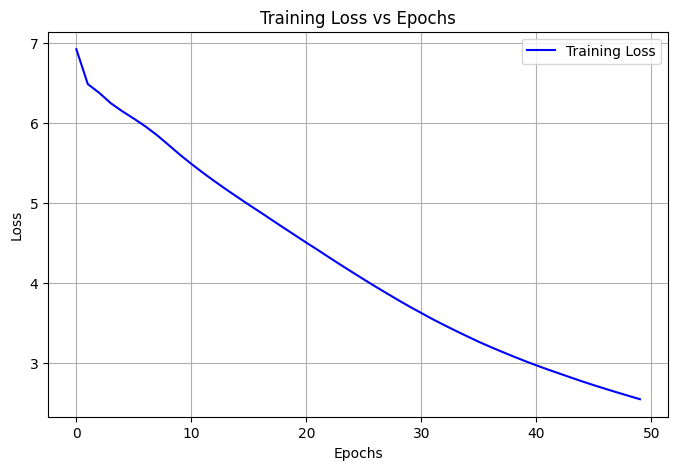

Final Training Loss: 2.4270
Final Training Accuracy: 0.4924


In [7]:
import matplotlib.pyplot as plt

history = model.fit(X, y, epochs=50, batch_size=128, verbose=1)

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], color='blue', label='Training Loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"Final Training Loss: {loss:.4f}")
print(f"Final Training Accuracy: {accuracy:.4f}")

In [8]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_next_word(seed_text, model, tokenizer, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')

    predicted_probs = model.predict(token_list, verbose=0)
    predicted_index = np.argmax(predicted_probs, axis=-1)[0]

    return tokenizer.index_word.get(predicted_index, "")

seed_texts = [
    "to be or not to",
    "alas poor",
    "the king is",
    "lord hamlet",
    "i am very"
]

print("--- Next Word Predictions ---")
for seed in seed_texts:
    next_word = predict_next_word(seed, model, tokenizer, max_sequence_len)
    print(f"Seed Text: '{seed}'\nPredicted Next Word: '{next_word}'\n")

--- Next Word Predictions ---
Seed Text: 'to be or not to'
Predicted Next Word: 'the'

Seed Text: 'alas poor'
Predicted Next Word: 'be'

Seed Text: 'the king is'
Predicted Next Word: 'the'

Seed Text: 'lord hamlet'
Predicted Next Word: 'is'

Seed Text: 'i am very'
Predicted Next Word: 'glad'

